# Эксперимент 2.3
Размер истории L-BFGS (`лаб2.pdf`, п. 2.3).


In [1]:
%load_ext autoreload
%autoreload 2


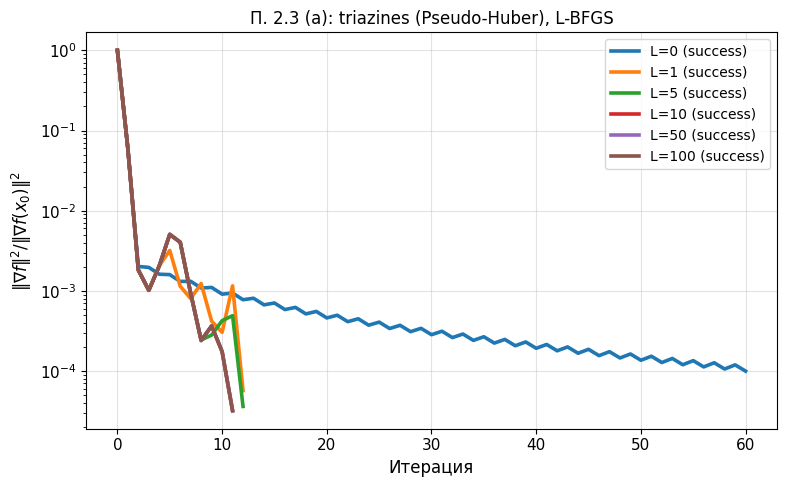

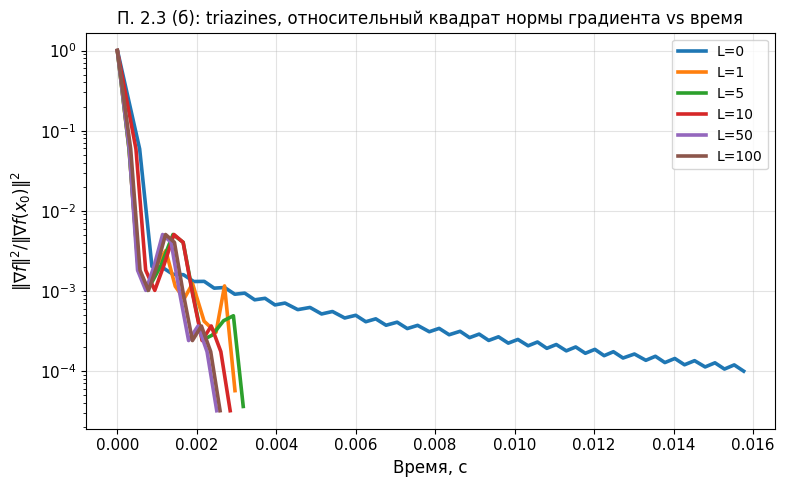

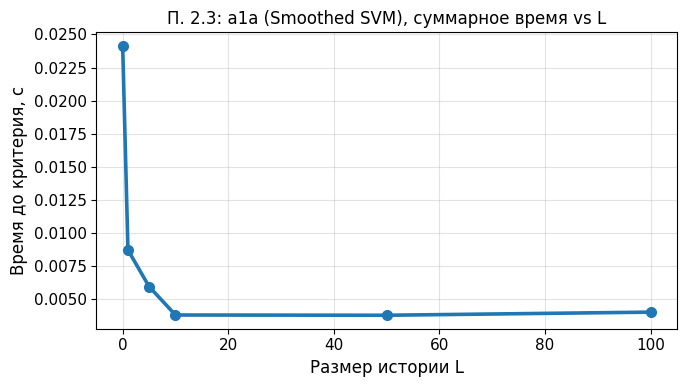

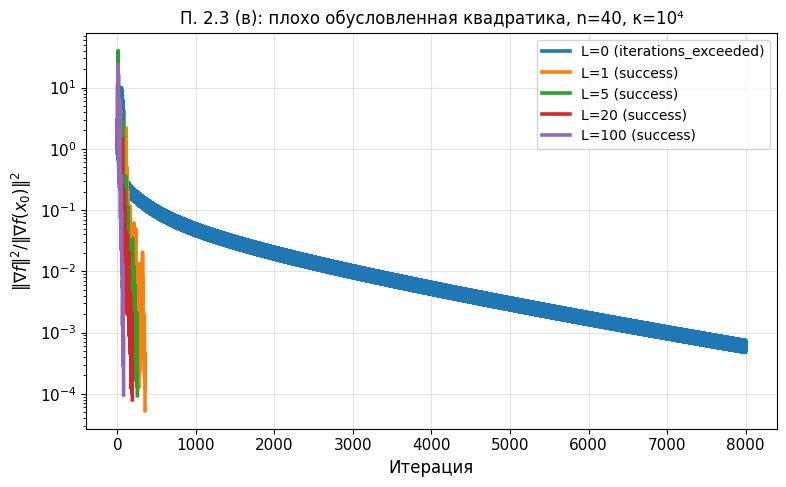

In [2]:
%matplotlib inline
import sys
import time
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
_src = _root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
from experiments_common import (
    TimedOracle,
    init_notebook,
    load_a1a,
    load_triazines,
    make_classification_oracle,
    make_regression_oracle,
    savefig_both,
    standard_regcoef,
    train_test_oracles_regression,
)
from ml_tools import sparse_oracle_ops
from optimization import (
    gradient_descent,
    hessian_free_newton,
    lbfgs,
    newton,
    newton_modified,
    nonlinear_conjugate_gradients,
    trust_region_steihaug_newton,
)
from oracles import NonConvexOracle, QuadraticOracle, beale_mesh_Z

init_notebook()

Xr, yr = load_triazines()
Xc, yc = load_a1a()
mr, mc = Xr.shape[0], Xc.shape[0]
reg_r, reg_c = standard_regcoef(mr), standard_regcoef(mc)
or_r = make_regression_oracle(Xr, yr, reg_r)
or_c = make_classification_oracle(Xc, yc, reg_c)
x0r = np.zeros(Xr.shape[1])
x0c = np.zeros(Xc.shape[1])
mems = [0, 1, 5, 10, 50, 100]
tol = 1e-4

series = {}
for L in mems:
    x, msg, h = lbfgs(
        or_r,
        x0r,
        tolerance=tol,
        max_iter=5000,
        memory_size=L,
        line_search_options={"method": "Wolfe", "alpha_0": 1.0},
        trace=True,
    )
    g0 = or_r.grad(x0r)
    g0n2 = float(np.dot(g0, g0))
    rel = [float(h["grad_norm"][i]) ** 2 / g0n2 for i in range(len(h["grad_norm"]))]
    series[L] = (np.arange(len(rel)), rel, h["time"], msg)

fig, ax = plt.subplots(figsize=(8, 5))
for L, (it, rel, tim, msg) in series.items():
    ax.semilogy(it, rel, label="L={} ({})".format(L, msg))
ax.set_xlabel("Итерация")
ax.set_ylabel(r"$\|\nabla f\|^2 / \|\nabla f(x_0)\|^2$")
ax.set_title("П. 2.3 (а): triazines (Pseudo-Huber), L-BFGS")
ax.legend()
fig.tight_layout()
savefig_both(fig, "exp23_triazines_mem")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for L, (it, rel, tim, msg) in series.items():
    ax.semilogy(tim, rel, label="L={}".format(L))
ax.set_xlabel("Время, с")
ax.set_ylabel(r"$\|\nabla f\|^2 / \|\nabla f(x_0)\|^2$")
ax.set_title("П. 2.3 (б): triazines, относительный квадрат нормы градиента vs время")
ax.legend()
fig.tight_layout()
savefig_both(fig, "exp23_triazines_mem_time")
plt.show()

times = []
for L in mems:
    t0 = time.perf_counter()
    lbfgs(
        or_c,
        x0c,
        tolerance=tol,
        max_iter=5000,
        memory_size=L,
        line_search_options={"method": "Wolfe", "alpha_0": 1.0},
        trace=False,
    )
    times.append(time.perf_counter() - t0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mems, times, "o-")
ax.set_xlabel("Размер истории L")
ax.set_ylabel("Время до критерия, с")
ax.set_title("П. 2.3: a1a (Smoothed SVM), суммарное время vs L")
fig.tight_layout()
savefig_both(fig, "exp23_a1a_time_vs_L")
plt.show()

nq = 40
kappa_bad = 1e4
lam = np.geomspace(1.0, kappa_bad, nq)
rng = np.random.default_rng(2)
Q, _ = np.linalg.qr(rng.standard_normal((nq, nq)))
Aq = Q @ np.diag(lam) @ Q.T
bq = rng.standard_normal(nq)
oq = QuadraticOracle(Aq, bq)
x0q = np.zeros(nq)
fig, ax = plt.subplots(figsize=(8, 5))
for L in (0, 1, 5, 20, 100):
    _, msg, h = lbfgs(
        oq,
        x0q,
        tolerance=1e-4,
        max_iter=8000,
        memory_size=L,
        line_search_options={"method": "Wolfe", "alpha_0": 1.0},
        trace=True,
    )
    g0 = oq.grad(x0q)
    g0n2 = float(np.dot(g0, g0))
    rel = [float(h["grad_norm"][i]) ** 2 / g0n2 for i in range(len(h["grad_norm"]))]
    ax.semilogy(np.arange(len(rel)), rel, label="L={} ({})".format(L, msg))
ax.set_xlabel("Итерация")
ax.set_ylabel(r"$\|\nabla f\|^2 / \|\nabla f(x_0)\|^2$")
ax.set_title("П. 2.3 (в): плохо обусловленная квадратическая функция, n=40, κ=10⁴")
ax.legend()
fig.tight_layout()
savefig_both(fig, "exp23_badly_conditioned_quad")
plt.show()
